DayChallenge

1.Définition et préparation des données

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, IntSlider
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')
# Charger le dataset
df = pd.read_csv(
    r"C:\Users\home\Desktop\DI-Bootcamp\Week2\Day4\Sample - Superstore.csv",
    encoding='latin1'
)
# Exploration initiale
print("Dataset Shape :", df.shape)
print("\nColonnes :")
print(df.columns.tolist())
print("\nInformations :")
print(df.info())
print("\nStatistiques descriptives :")
print(df.describe())
print("\nValeurs manquantes :")
print(df.isnull().sum())
# Vérification des doublons
print("\nNombre de doublons :", df.duplicated().sum())
# Suppression des doublons
df = df.drop_duplicates()
# Gestion des valeurs manquantes
if 'Postal Code' in df.columns:
    df['Postal Code'] = df['Postal Code'].fillna(0)
# Conversion des dates
date_columns = ['Order Date', 'Ship Date']
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])
print("\nTypes après conversion :")
print(df[date_columns].dtypes)
# Création de nouvelles variables
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')
print("\nNouvelles variables créées :")
print(df[['Sales', 'Profit', 'Profit Margin',
          'Order Year', 'Order Month']].head())

Dataset Shape : (9994, 21)

Colonnes :
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Informations :
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code 

2.Analyse exploratoire approfondie (Matplotlib)

In [ ]:
# =====================================
# VENTES PAR ETAT
# =====================================
# Calcul des ventes par Etat
state_sales = (
    df.groupby('State')['Sales']
    .sum()
    .sort_values()
)
# Fonction interactive
def plot_top_states(top_n=10):

    plt.figure(figsize=(12,6))
    top_states = state_sales.tail(top_n)
    plt.barh(
        top_states.index,
        top_states.values
    )
    plt.xlabel('Total Sales ($)')
    plt.ylabel('State')
    plt.title(
        f'Top {top_n} States by Sales',
        fontsize=15,
        fontweight='bold'
    )
    # Ajouter les valeurs
    for i, value in enumerate(top_states.values):
        plt.text(
            value,
            i,
            f' ${value:,.0f}',
            va='center'
        )
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"Nombre total d'États : {len(state_sales)}")
    print(f"Ventes cumulées du Top {top_n} : ${top_states.sum():,.2f}")
# Slider interactif
interact(
    plot_top_states,
    top_n=IntSlider(
        min=5,
        max=25,
        step=1,
        value=10,
        description='Top N'
    )
);

interactive(children=(IntSlider(value=10, description='Top N', max=25, min=5), Output()), _dom_classes=('widge…

3.Communiquer des informations (Seaborn)

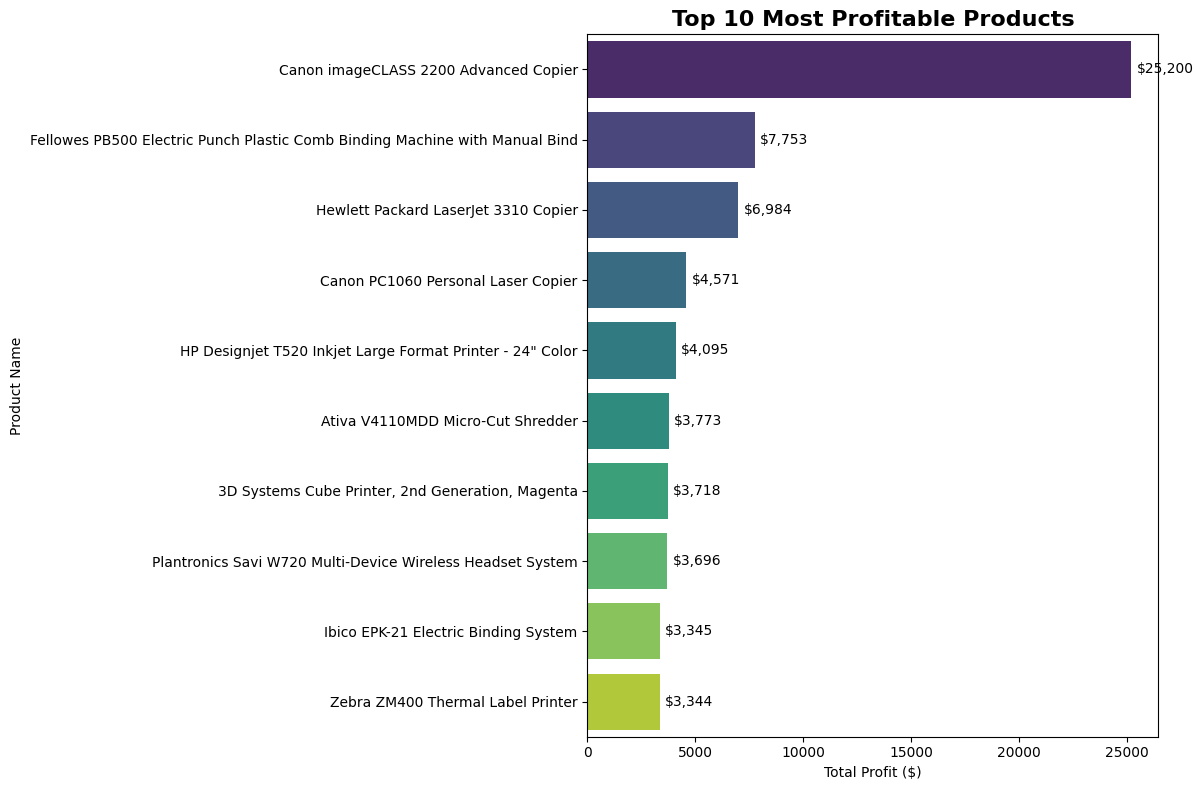

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 produits les plus rentables
product_profit = (
    df.groupby('Product Name')['Profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,8))

ax = sns.barplot(
    x=product_profit.values,
    y=product_profit.index,
    palette='viridis'
)

plt.title('Top 10 Most Profitable Products', fontsize=16, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('Product Name')

for i, value in enumerate(product_profit.values):
    ax.text(
        value + product_profit.max()*0.01,
        i,
        f'${value:,.0f}',
        va='center'
    )

plt.tight_layout()
plt.show()

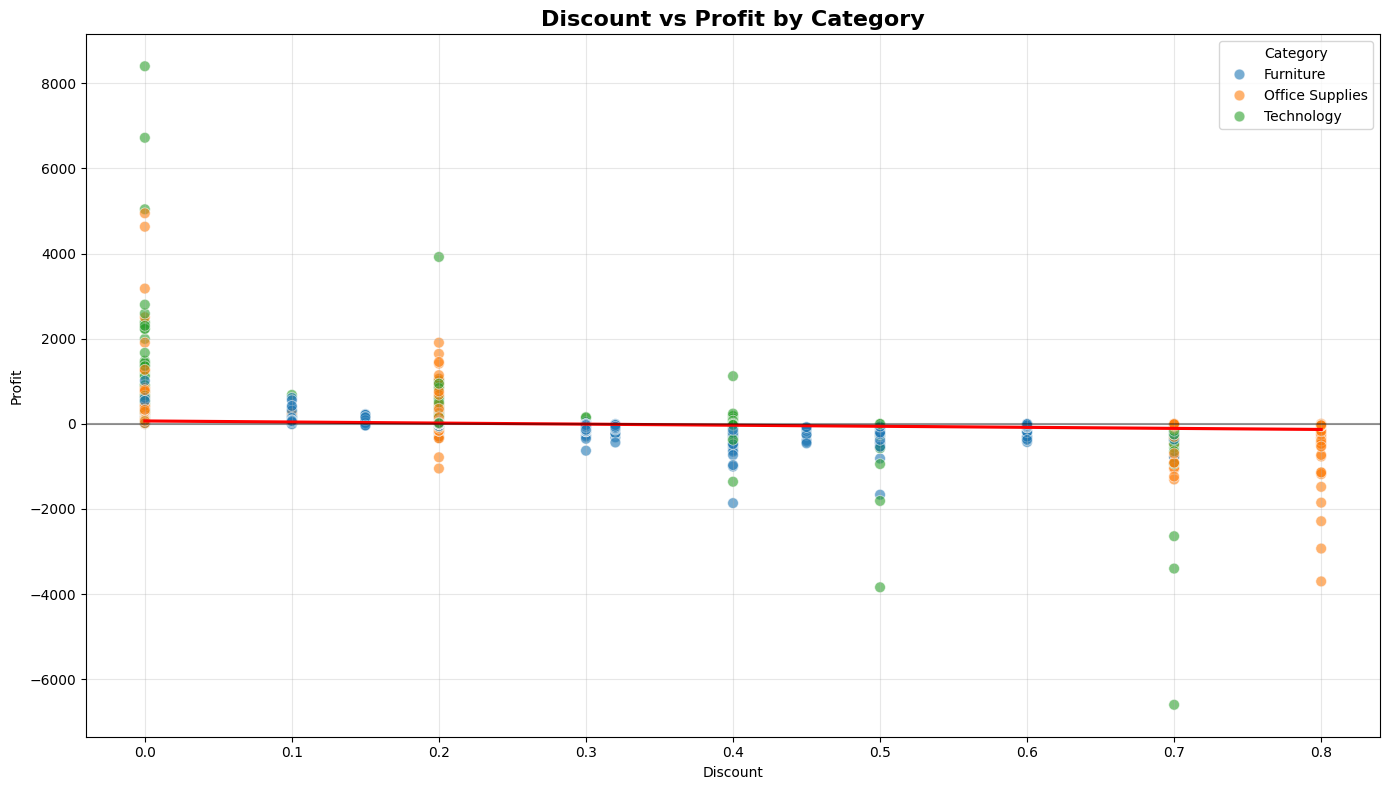

In [5]:
plt.figure(figsize=(14,8))
sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    hue='Category',
    alpha=0.6,
    s=60
)

sns.regplot(
    data=df,
    x='Discount',
    y='Profit',
    scatter=False,
    color='red'
)

plt.axhline(y=0, color='black', alpha=0.4)

plt.title('Discount vs Profit by Category', fontsize=16, fontweight='bold')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

4.Revue de la méthodologie et des outils

# Comparative Evaluation: Matplotlib vs Seaborn
## Matplotlib
### Advantages
- Offers fine-grained control over every aspect of a visualization.
- Integrates easily with interactive widgets such as ipywidgets.
- Excellent for building customized dashboards and complex layouts.
- Generally faster for basic plotting tasks.
### Limitations
- Requires more code to achieve attractive visualizations.
- Default styling is less visually appealing.
## Seaborn
### Advantages
- Built on top of Matplotlib with cleaner syntax.
- Provides attractive default styles and color palettes.
- Includes built-in statistical visualizations such as regression plots.
- Ideal for categorical and exploratory data analysis.
### Limitations
- Less flexible than Matplotlib for highly customized visualizations.
- Slightly slower due to additional abstraction layers.
## Recommendation
For rapid exploratory analysis and interactive dashboards, Matplotlib is preferred because it offers greater flexibility and integrates efficiently with widgets.
For executive presentations and stakeholder reports, Seaborn is recommended because it provides professional-looking visualizations, built-in statistical capabilities, and improved readability with minimal coding effort.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import time
print("=== LIBRARY COMPARISON ANALYSIS ===\n")
print("MATPLOTLIB STRENGTHS")
print("• Fine-grained control over plots")
print("• Excellent widget integration")
print("• Flexible customization")
print("• Fast rendering for simple charts\n")
print("SEABORN STRENGTHS")
print("• Beautiful default themes")
print("• Built-in statistical plots")
print("• Automatic color handling")
print("• Easier categorical analysis\n")
# Performance comparison
start = time.time()
plt.figure(figsize=(8,6))
plt.plot(df.groupby('Order Year')['Sales'].sum())
plt.close()
matplotlib_time = time.time() - start
start = time.time()
plt.figure(figsize=(8,6))
sns.lineplot(
    data=df.groupby('Order Year')['Sales']
    .sum()
    .reset_index(),
    x='Order Year',
    y='Sales'
)
plt.close()
seaborn_time = time.time() - start
print("SPEED COMPARISON")
print(f"Matplotlib: {matplotlib_time:.4f} seconds")
print(f"Seaborn: {seaborn_time:.4f} seconds")

=== LIBRARY COMPARISON ANALYSIS ===

MATPLOTLIB STRENGTHS
• Fine-grained control over plots
• Excellent widget integration
• Flexible customization
• Fast rendering for simple charts

SEABORN STRENGTHS
• Beautiful default themes
• Built-in statistical plots
• Automatic color handling
• Easier categorical analysis

SPEED COMPARISON
Matplotlib: 0.0406 seconds
Seaborn: 0.0446 seconds


5.Livrable final

# Executive Summary
## Key Findings
### 1. Overall Business Performance
- The Superstore generated significant revenue and maintained a positive overall profit margin.
- Sales performance varied across categories and regions.
### 2. Geographic Performance
- A small number of states contributed a large share of total sales.
- Sales activity is concentrated in top-performing states, indicating potential dependence on specific markets.
### 3. Product Performance
- The Technology category generated the highest sales and profitability.
- A limited number of products contributed disproportionately to total profit.
### 4. Discount Impact
- High discount levels are strongly associated with lower profitability.
- Discounts above 20% frequently lead to financial losses.
### 5. Strategic Recommendations
- Focus marketing efforts on top-performing products and regions.
- Monitor discount policies carefully, especially for low-margin categories.
- Expand successful product strategies to underperforming regions.

In [8]:
# =====================================
# EXECUTIVE SUMMARY
# =====================================
print("="*50)
print("EXECUTIVE SUMMARY - KEY FINDINGS")
print("="*50)
# Business performance
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100
print("\n BUSINESS PERFORMANCE")
print(f"Total Revenue : ${total_sales:,.2f}")
print(f"Total Profit  : ${total_profit:,.2f}")
print(f"Profit Margin : {profit_margin:.2f}%")
# Geographic performance
state_sales = df.groupby('State')['Sales'].sum().sort_values()
top_state = state_sales.idxmax()
top_state_sales = state_sales.max()
print("\nGEOGRAPHIC PERFORMANCE")
print(f"Top State : {top_state}")
print(f"Sales     : ${top_state_sales:,.2f}")
top5_share = (state_sales.tail(5).sum() / total_sales) * 100
print(f"Top 5 States Contribution : {top5_share:.2f}%")
# Product performance
category_sales = df.groupby('Category')['Sales'].sum()
top_category = category_sales.idxmax()
product_profit = (
    df.groupby('Product Name')['Profit']
    .sum()
    .sort_values(ascending=False)
)
print("\n PRODUCT PERFORMANCE")
print(f"Top Category : {top_category}")
print(f"Most Profitable Product : {product_profit.index[0]}")
# Discount analysis
high_discount = df[df['Discount'] > 0.20]
loss_rate = (
    (high_discount['Profit'] < 0).mean()
) * 100
print("\n DISCOUNT STRATEGY")
print(f"Loss Rate (>20% Discount): {loss_rate:.1f}%")
print("\n RECOMMENDATIONS")
print("• Limit standard discounts to 20% or less.")
print("• Focus on high-profit products.")
print("• Increase investment in top-performing states.")
print("• Review low-profit categories regularly.")
print("• Use data-driven pricing strategies.")

EXECUTIVE SUMMARY - KEY FINDINGS

 BUSINESS PERFORMANCE
Total Revenue : $2,297,200.86
Total Profit  : $286,397.02
Profit Margin : 12.47%

GEOGRAPHIC PERFORMANCE
Top State : California
Sales     : $457,687.63
Top 5 States Contribution : 51.97%

 PRODUCT PERFORMANCE
Top Category : Technology
Most Profitable Product : Canon imageCLASS 2200 Advanced Copier

 DISCOUNT STRATEGY
Loss Rate (>20% Discount): 96.8%

 RECOMMENDATIONS
• Limit standard discounts to 20% or less.
• Focus on high-profit products.
• Increase investment in top-performing states.
• Review low-profit categories regularly.
• Use data-driven pricing strategies.


 Défis avancés optionnels

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv(
    r"C:\Users\home\Desktop\DI-Bootcamp\Week2\Day4\Sample - Superstore.csv",
    encoding="latin1"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [11]:
print("Shape:", df.shape)
# doublons
df = df.drop_duplicates()
# dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
# features
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

Shape: (9994, 21)


In [12]:
monthly = df.groupby(['Order Month-Year', 'Category'])['Sales'].sum().reset_index()
monthly['Date'] = monthly['Order Month-Year'].dt.to_timestamp()

def plot_sales(category='All'):

    plt.figure(figsize=(12,5))

    if category == 'All':
        data = df.groupby('Order Month-Year')['Sales'].sum()
        plt.plot(data.index.to_timestamp(), data.values)
        plt.title("Ventes mensuelles - Total")
    else:
        data = monthly[monthly['Category'] == category]
        plt.plot(data['Date'], data['Sales'])
        plt.title(f"Ventes - {category}")

    plt.xticks(rotation=45)
    plt.grid()
    plt.show()

interact(plot_sales, category=['All'] + list(df['Category'].unique()))

interactive(children=(Dropdown(description='category', options=('All', 'Furniture', 'Office Supplies', 'Techno…

<function __main__.plot_sales(category='All')>

In [13]:
state_sales = df.groupby('State')['Sales'].sum().sort_values()

def top_states(n=10):
    top = state_sales.tail(n)

    plt.figure(figsize=(10,6))
    plt.barh(top.index, top.values)
    plt.title(f"Top {n} États")
    plt.show()

interact(top_states, n=(5,20))

interactive(children=(IntSlider(value=10, description='n', max=20, min=5), Output()), _dom_classes=('widget-in…

<function __main__.top_states(n=10)>

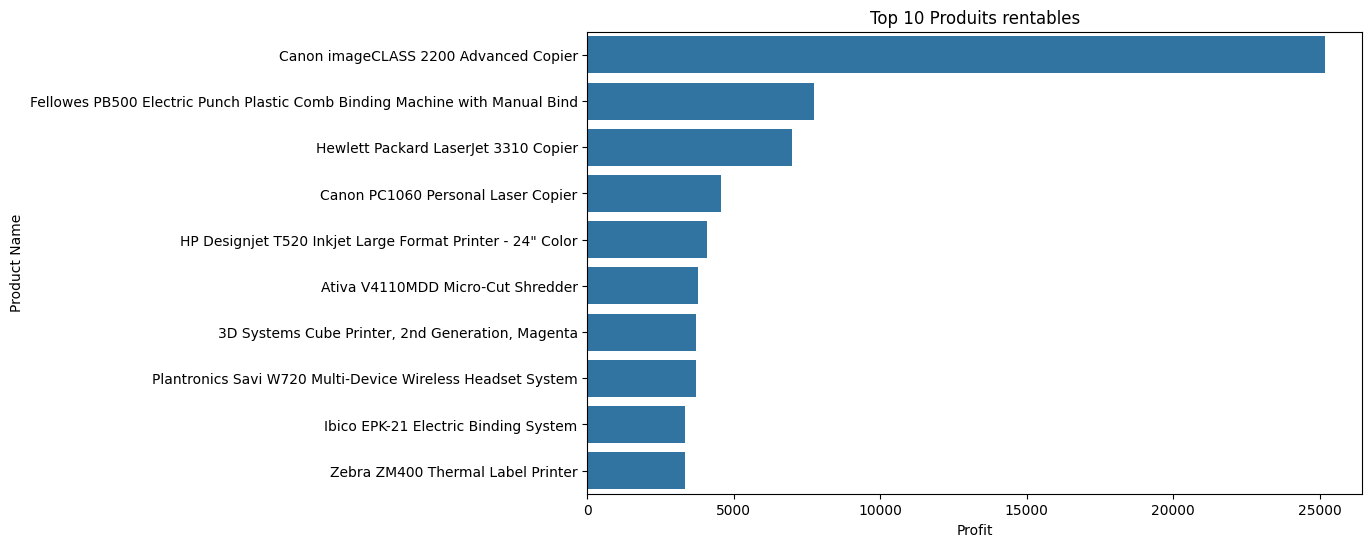

In [14]:
top_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Produits rentables")
plt.xlabel("Profit")
plt.show()

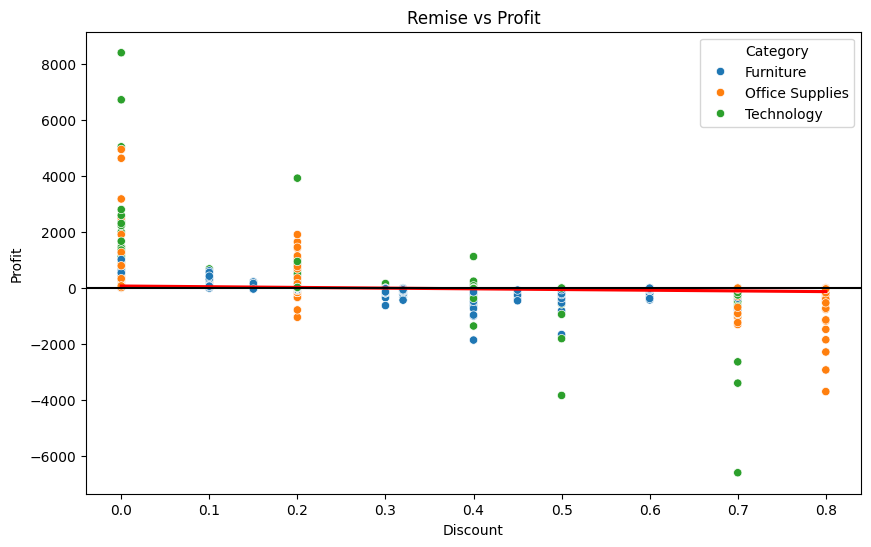

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category')
sns.regplot(data=df, x='Discount', y='Profit', scatter=False, color='red')

plt.axhline(0, color='black')
plt.title("Remise vs Profit")
plt.show()

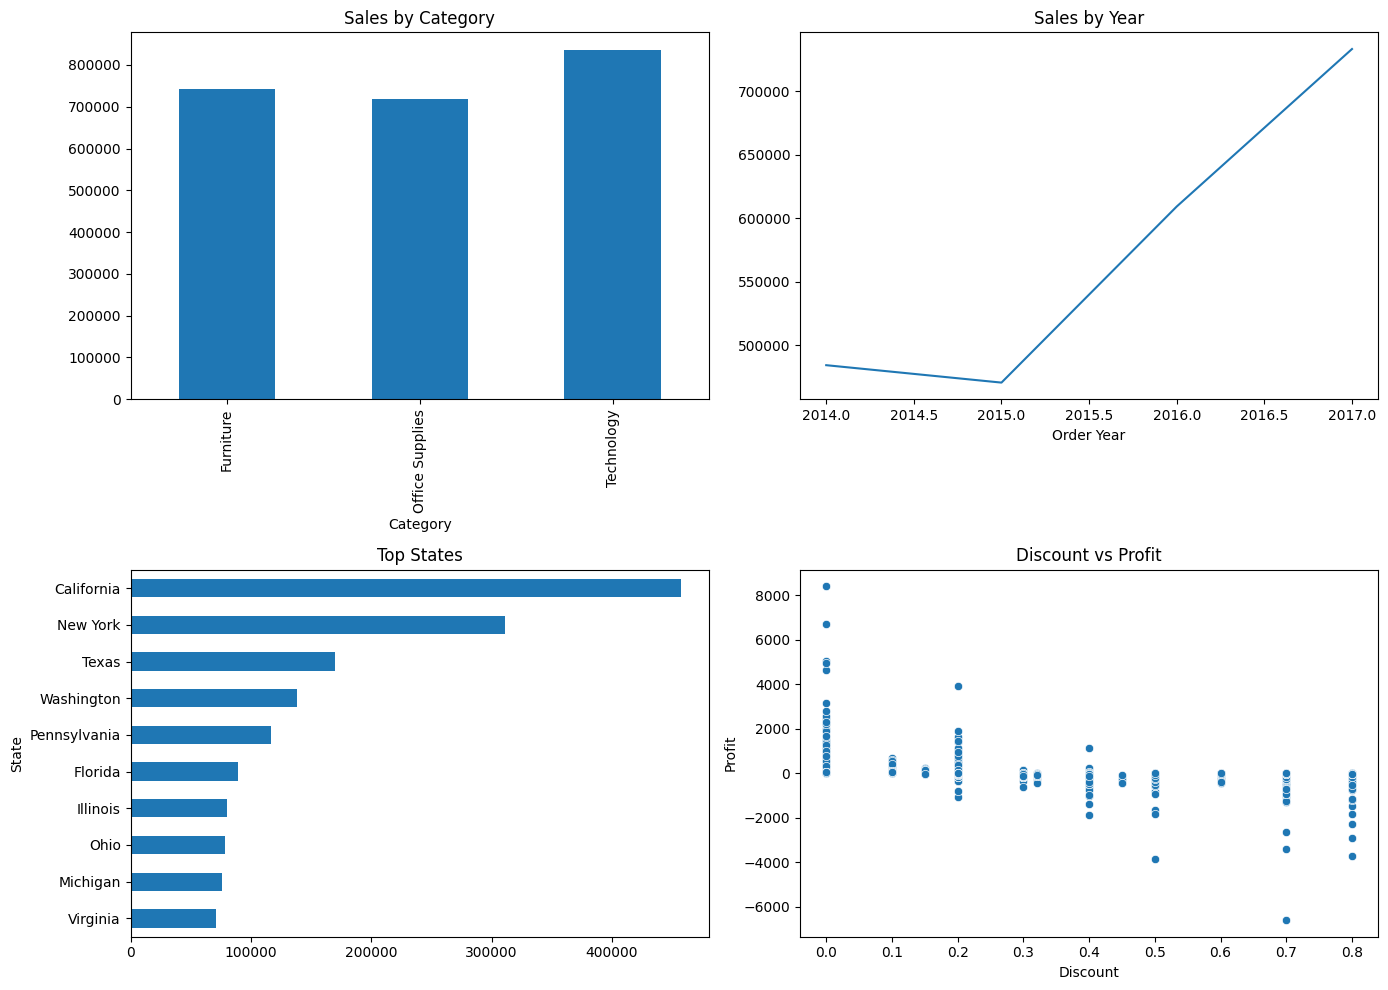

In [16]:
def dashboard():

    fig, ax = plt.subplots(2,2, figsize=(14,10))

    df.groupby('Category')['Sales'].sum().plot(kind='bar', ax=ax[0,0])
    ax[0,0].set_title("Sales by Category")

    df.groupby('Order Year')['Sales'].sum().plot(ax=ax[0,1])
    ax[0,1].set_title("Sales by Year")

    state_sales.tail(10).plot(kind='barh', ax=ax[1,0])
    ax[1,0].set_title("Top States")

    sns.scatterplot(data=df, x='Discount', y='Profit', ax=ax[1,1])
    ax[1,1].set_title("Discount vs Profit")

    plt.tight_layout()
    plt.show()

dashboard()